# Transformada Discreta del Coseno

In [99]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D 

In [102]:
f = 8
t = np.linspace(0, 1, 100)
real_part = np.cos(2*np.pi*f*t)
imag_part = np.sin(2*np.pi*f*t)

theta = np.linspace(0, 2*np.pi, 100)
r = np.cos(theta)
i = np.sin(theta)

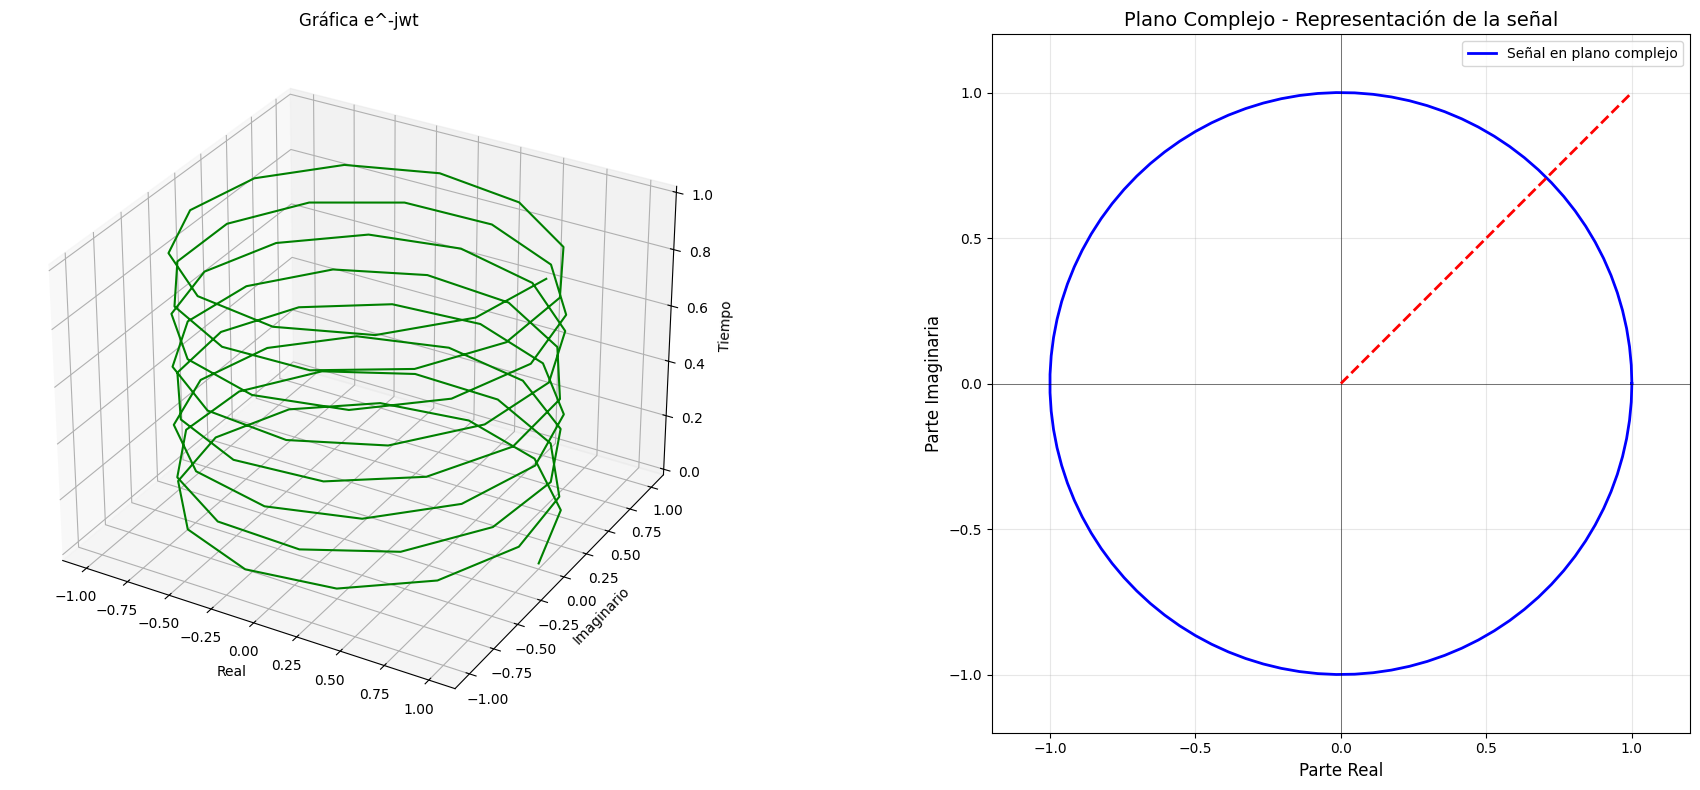

In [103]:
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(20, 8))

# Primer subplot: 3D (e^-jwt)
ax = fig.add_subplot(1, 2, 1, projection='3d')
ax.plot3D(real_part, imag_part, t, 'green')
ax.set_xlabel('Real')
ax.set_ylabel('Imaginario')
ax.set_zlabel('Tiempo')
ax.set_title('Gráfica e^-jwt')

# Segundo subplot: Plano complejo
ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(r, i, 'b-', linewidth=2, label='Señal en plano complejo')

# Dibujar ejes del plano complejo
ax2.axhline(y=0, color='k', linestyle='-', linewidth=0.5, alpha=0.7)  # Eje real
ax2.axvline(x=0, color='k', linestyle='-', linewidth=0.5, alpha=0.7)  # Eje imaginario

angle = np.pi/4  # 45 grados
x_diag = np.linspace(0, 1, 100)
y_diag = x_diag * np.tan(angle)
ax2.plot(x_diag, y_diag, 'r--', linewidth=2)

# Configurar el gráfico
ax2.set_xlabel('Parte Real', fontsize=12)
ax2.set_ylabel('Parte Imaginaria', fontsize=12)
ax2.set_title('Plano Complejo - Representación de la señal', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_aspect('equal')  # Para que el círculo se vea como círculo, no elipse
ax2.legend(loc='upper right')

# Ajustar límites para ver bien el círculo unitario
max_val = 1.2
ax2.set_xlim(-max_val, max_val)
ax2.set_ylim(-max_val, max_val)

plt.tight_layout()
plt.show()


In [109]:
img = cv2.imread("img/espiral.jpg", cv2.IMREAD_GRAYSCALE)
img = np.float32(img)
dct = cv2.dct(img)
dct_abs = np.abs(dct)
dct_spec = np.log(dct_abs + 1)

fft = np.fft.fft2(img)
fft_2 = np.fft.fftshift(fft)
fft_abs = np.abs(fft)
fft_spec = np.log(fft_abs + 1)

fft_abs_2 = np.abs(fft_2)
fft_spec_2 = np.log(fft_abs_2 + 1)

n,m = fft_spec.shape
fft_spec_seg = fft_spec_2[0:n//2, :]#0:m//2]

fft_phase = np.angle(fft_2)

In [110]:
h = ( (fft_phase + np.pi) / (2 * np.pi) * 179 ).astype(np.uint8)
s = np.uint8(255 * np.ones_like(fft_phase))
v = cv2.normalize(fft_spec_2, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

mag_phase = cv2.merge([h, s, v])
mag_phase_RGB = cv2.cvtColor(mag_phase, cv2.COLOR_HSV2RGB)

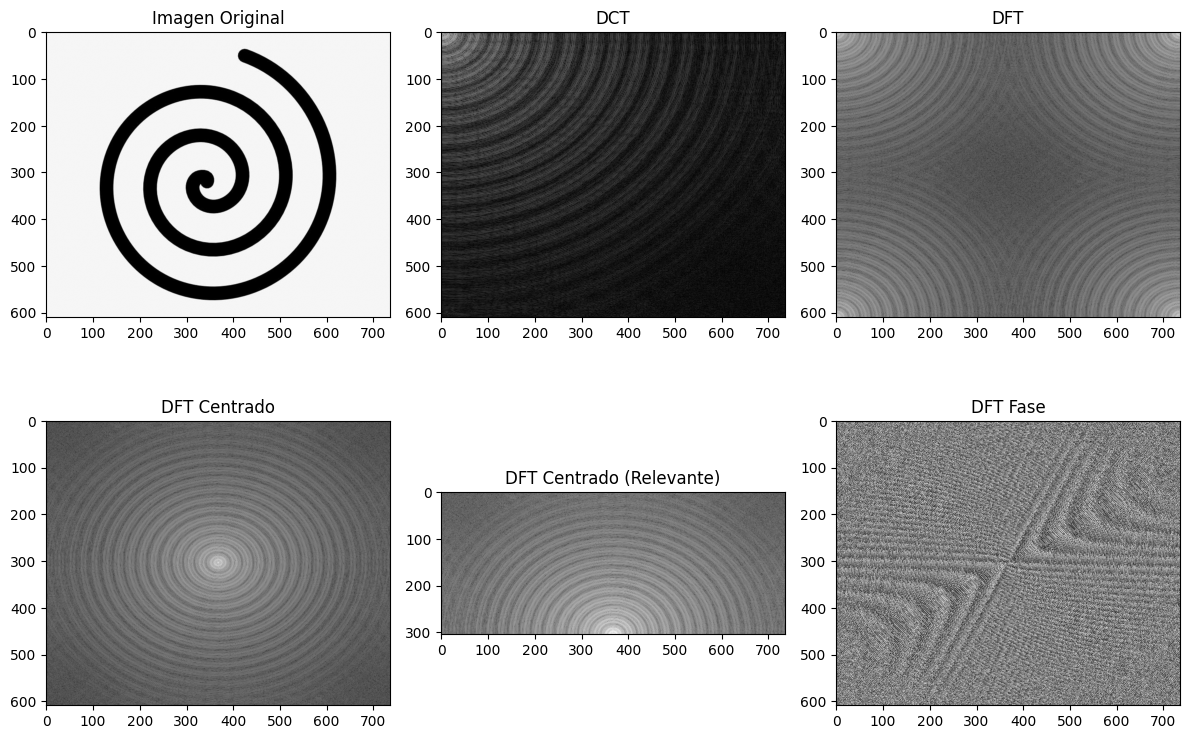

In [111]:
fig, axs = plt.subplots(2,3, figsize=(12,8))

axs[0,0].imshow(img, cmap="gray")
axs[0,0].set_title("Imagen Original")

axs[0,1].imshow(dct_spec, cmap="gray")
axs[0,1].set_title("DCT")

axs[0,2].imshow(fft_spec, cmap="gray")
axs[0,2].set_title("DFT")

axs[1,0].imshow(fft_spec_2, cmap="gray")
axs[1,0].set_title("DFT Centrado")

axs[1,1].imshow(fft_spec_seg, cmap="gray")
axs[1,1].set_title("DFT Centrado (Relevante)")

axs[1,2].imshow(fft_phase, cmap="gray")
axs[1,2].set_title("DFT Fase")

plt.tight_layout()
plt.show()

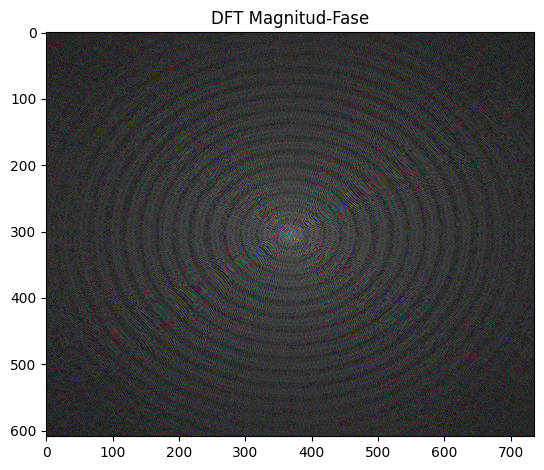

In [112]:
plt.imshow(mag_phase_RGB)
plt.title("DFT Magnitud-Fase")
plt.tight_layout()
plt.show()